Teams in dataset: ['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']
Top 5 rows:
                          team1                        team2  \
0  Royal Challengers Bangalore        Kolkata Knight Riders   
1              Kings XI Punjab          Chennai Super Kings   
2             Delhi Daredevils             Rajasthan Royals   
3               Mumbai Indians  Royal Challengers Bangalore   
4        Kolkata Knight Riders              Deccan Chargers   

                   toss_winner toss_decision  \
0  Royal Challengers Bangalore         field   
1          Chennai Super Kings           bat   
2             Rajasthan Royals           

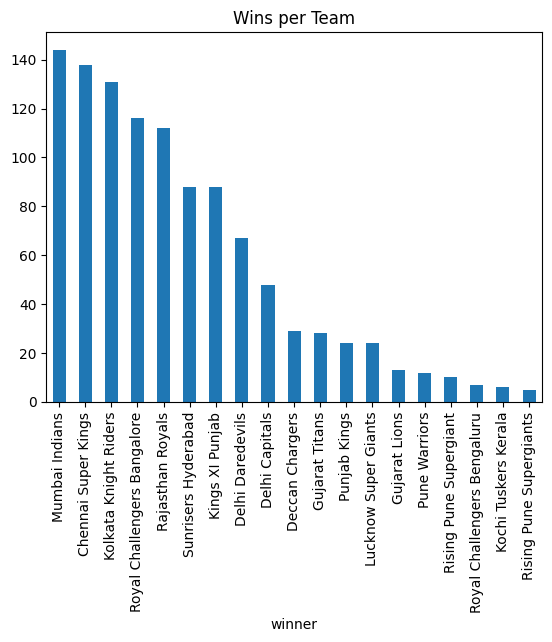

Toss Effect Table:
 winner                       Chennai Super Kings  Deccan Chargers  \
toss_winner                                                         
Chennai Super Kings                           75                1   
Deccan Chargers                                2               19   
Delhi Capitals                                 3                0   
Delhi Daredevils                               5                0   
Gujarat Lions                                  0                0   
Gujarat Titans                                 2                0   
Kings XI Punjab                                4                2   
Kochi Tuskers Kerala                           0                1   
Kolkata Knight Riders                         10                1   
Lucknow Super Giants                           1                0   
Mumbai Indians                                 6                0   
Pune Warriors                                  3                0   
Punjab Kings  

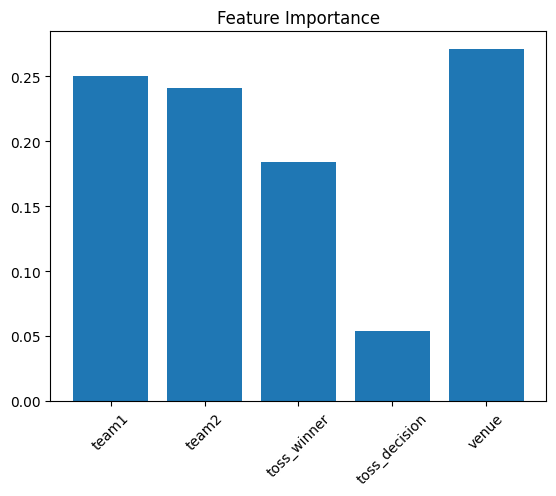

Sample Prediction: 16


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("matches.csv")
df = df[['team1','team2','toss_winner','toss_decision','venue','winner']]
df = df.dropna()

# Exploratory Data Analysis (EDA)
print("Teams in dataset:", df['team1'].unique())
print("Top 5 rows:\n", df.head())

df['winner'].value_counts().plot(kind='bar', title='Wins per Team')
plt.show()

toss_effect = pd.crosstab(df['toss_winner'], df['winner'])
print("Toss Effect Table:\n", toss_effect)

# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('winner', axis=1)
y = df['winner']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.bar(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# Sample Prediction Function
def predict_winner(team1, team2, toss_winner, toss_decision, venue):
    sample = pd.DataFrame([[team1, team2, toss_winner, toss_decision, venue]], columns=X.columns)
    return model.predict(sample)[0]

print("Sample Prediction:", predict_winner(*X.iloc[0]))